In [1]:
import pandas as pd

In [2]:
import os
import json
import requests
from dotenv import load_dotenv

load_dotenv()

ACCESS_TOKEN = os.getenv("META_ACCESS_TOKEN")
AD_ACCOUNT_ID = os.getenv("META_AD_ACCOUNT_ID")  # Should include 'act_'

BASE_URL = "https://graph.facebook.com/v24.0"


def get_delivery_estimate(targeting_spec, optimization_goal="REACH"):
    """
    Call Meta delivery_estimate endpoint for a given targeting_spec.
    Returns parsed JSON dict or raises an error.
    """
    if not ACCESS_TOKEN or not AD_ACCOUNT_ID:
        raise ValueError("Missing META_ACCESS_TOKEN or META_AD_ACCOUNT_ID env vars.")

    url = f"{BASE_URL}/{AD_ACCOUNT_ID}/delivery_estimate"
    params = {
        "access_token": ACCESS_TOKEN,
        "optimization_goal": optimization_goal,
        # targeting_spec must be JSON-encoded string
        "targeting_spec": json.dumps(targeting_spec),
    }

    resp = requests.get(url, params=params)
    data = resp.json()
    if "error" in data:
        raise RuntimeError(f"Meta API error: {data['error']}")
    return data


def summarize_estimate(estimate):
    """
    Extract DAU and central MAU from a delivery_estimate response.
    Returns (dau, mau_mid, mau_low, mau_high).
    """
    if not estimate.get("data"):
        return None, None, None, None

    e = estimate["data"][0]
    dau = e.get("estimate_dau")
    low = e.get("estimate_mau_lower_bound")
    high = e.get("estimate_mau_upper_bound")

    mau_mid = (low + high) / 2 if low is not None and high is not None else None
    return dau, mau_mid, low, high


In [ ]:
def make_targeting_country_ma(gender=None, age_min=18, age_max=65):
    """
    Build targeting_spec for Morocco as a whole.
    gender: None (all), 1 (female), 2 (male)
    """
    spec = {
        "geo_locations": {"countries": ["MA"]},
        "age_min": age_min,
        "age_max": age_max,
    }
    if gender in (1, 2):
        spec["genders"] = [gender]
    return spec


# 1) All users
nat_all_est = get_delivery_estimate(make_targeting_country_ma(gender=None))
nat_all_dau, nat_all_mau, _, _ = summarize_estimate(nat_all_est)

# 2) Women
nat_f_est = get_delivery_estimate(make_targeting_country_ma(gender=1))
nat_f_dau, nat_f_mau, _, _ = summarize_estimate(nat_f_est)

# 3) Men
nat_m_est = get_delivery_estimate(make_targeting_country_ma(gender=2))
nat_m_dau, nat_m_mau, _, _ = summarize_estimate(nat_m_est)

print("National estimates (18+):")
print(f"All:    DAU={nat_all_dau}, MAU≈{nat_all_mau}")
print(f"Women:  DAU={nat_f_dau}, MAU≈{nat_f_mau}")
print(f"Men:    DAU={nat_m_dau}, MAU≈{nat_m_mau}")

# F/M index at national level
if nat_f_mau and nat_m_mau:
    fm_index_nat = nat_f_mau / nat_m_mau
    print(f"F/M index (national, MAU-based) ≈ {fm_index_nat:.3f}")


National estimates (18+):
All:    DAU=17277635, MAU≈27850000.0
Women:  DAU=9973035, MAU≈15750000.0
Men:    DAU=7072285, MAU≈11900000.0
F/M index (national, MAU-based) ≈ 1.324


In [4]:
def get_regions(country_code="MA"):
    """
    Retrieve all available 'region' geo locations for a given country code.
    Returns list of dicts with keys: key, name, country_code.
    """
    url = f"{BASE_URL}/search"
    params = {
        "access_token": ACCESS_TOKEN,
        "type": "adgeolocation",
        "location_types": "['region']",
        "country_code": country_code,
        "limit": 200,
    }
    resp = requests.get(url, params=params)
    data = resp.json()
    if "error" in data:
        raise RuntimeError(f"Meta API error (regions): {data['error']}")
    return data.get("data", [])


regions_ma = get_regions("MA")
print("Available regions in MA:")
for r in regions_ma:
    print(f"- key={r['key']}, name={r['name']}")


Available regions in MA:
- key=2228, name=Taza-Al Hoceima-Taounate
- key=4388, name=Souss-Massa-Drâa
- key=4387, name=Dakhla-Oued Ed-Dahab
- key=4389, name=Gharb-Chrarda-Béni Hssen
- key=4393, name=Tadla-Azilal
- key=2206, name=Grand Casablanca
- key=4392, name=Doukkala-Abda
- key=4390, name=Chaouia-Ouardigha
- key=2232, name=Laâyoune-Boujdour-Sakia El Hamra
- key=2226, name=Tangier-Tetouan
- key=2223, name=Rabat-Salé-Zemmour-Zaer
- key=2212, name=Fès-Boulemane
- key=2230, name=Guelmim-Es Semara
- key=4391, name=Oriental
- key=2218, name=Marrakesh-Tensift-El Haouz
- key=2219, name=Meknès-Tafilalet


In [5]:
def make_targeting_region(region_key, gender=None, age_min=18, age_max=65):
    """
    Build targeting_spec for a specific region (Meta region key).
    gender: None (all), 1 (female), 2 (male)
    """
    spec = {
        "geo_locations": {
            "regions": [{"key": region_key}],
        },
        "age_min": age_min,
        "age_max": age_max,
    }
    if gender in (1, 2):
        spec["genders"] = [gender]
    return spec


def get_region_rows_with_all_genders(regions, age_min=18, age_max=65):
    """
    For each region, compute audience estimates for:
    - ALL (no gender filter)
    - F (genders=[1])
    - M (genders=[2])
    Returns a list of dict rows compatible with region_rows.
    """
    rows = []
    gender_map = {
        "ALL": None,
        "F": 1,
        "M": 2,
    }

    for r in regions:
        region_key = r["key"]
        region_name = r.get("name", region_key)

        for gender_label, gender_code in gender_map.items():
            targeting_spec = make_targeting_region(
                region_key=region_key,
                gender=gender_code,
                age_min=age_min,
                age_max=age_max,
            )

            est = get_delivery_estimate(targeting_spec)
            dau, mau_mid, mau_low, mau_high = summarize_estimate(est)

            row = {
                "region_key": region_key,
                "region_name": region_name,
                "gender": gender_label,
                "dau": dau,
                "mau_mid": mau_mid,
                "mau_low": mau_low,
                "mau_high": mau_high,
            }
            rows.append(row)

    return rows
region_rows = get_region_rows_with_all_genders(regions_ma)

for row in region_rows[:10]:
    print(row)


{'region_key': '2228', 'region_name': 'Taza-Al Hoceima-Taounate', 'gender': 'ALL', 'dau': 354350, 'mau_mid': 563950.0, 'mau_low': 518200, 'mau_high': 609700}
{'region_key': '2228', 'region_name': 'Taza-Al Hoceima-Taounate', 'gender': 'F', 'dau': 237163, 'mau_mid': 372400.0, 'mau_low': 342200, 'mau_high': 402600}
{'region_key': '2228', 'region_name': 'Taza-Al Hoceima-Taounate', 'gender': 'M', 'dau': 115534, 'mau_mid': 191400.0, 'mau_low': 175900, 'mau_high': 206900}
{'region_key': '4388', 'region_name': 'Souss-Massa-Drâa', 'gender': 'ALL', 'dau': 1538672, 'mau_mid': 2350000.0, 'mau_low': 2200000, 'mau_high': 2500000}
{'region_key': '4388', 'region_name': 'Souss-Massa-Drâa', 'gender': 'F', 'dau': 903747, 'mau_mid': 1400000.0, 'mau_low': 1300000, 'mau_high': 1500000}
{'region_key': '4388', 'region_name': 'Souss-Massa-Drâa', 'gender': 'M', 'dau': 560595, 'mau_mid': 939350.0, 'mau_low': 878700, 'mau_high': 1000000}
{'region_key': '4387', 'region_name': 'Dakhla-Oued Ed-Dahab', 'gender': 'ALL

In [6]:
# National: all, female, male (same structure as region_rows)

# All users
nat_all_est = get_delivery_estimate(make_targeting_country_ma(gender=None))
nat_all_dau, nat_all_mau_mid, nat_all_mau_low, nat_all_mau_high = summarize_estimate(nat_all_est)

# Women
nat_f_est = get_delivery_estimate(make_targeting_country_ma(gender=1))
nat_f_dau, nat_f_mau_mid, nat_f_mau_low, nat_f_mau_high = summarize_estimate(nat_f_est)

# Men
nat_m_est = get_delivery_estimate(make_targeting_country_ma(gender=2))
nat_m_dau, nat_m_mau_mid, nat_m_mau_low, nat_m_mau_high = summarize_estimate(nat_m_est)


# Build rows in the exact same schema as region_rows
nat_rows = [
    {
        "region_key": "MA",
        "region_name": "Morocco (all)",
        "gender": "ALL",
        "dau": nat_all_dau,
        "mau_mid": nat_all_mau_mid,
        "mau_low": nat_all_mau_low,
        "mau_high": nat_all_mau_high,
    },
    {
        "region_key": "MA",
        "region_name": "Morocco (all)",
        "gender": "F",
        "dau": nat_f_dau,
        "mau_mid": nat_f_mau_mid,
        "mau_low": nat_f_mau_low,
        "mau_high": nat_f_mau_high,
    },
    {
        "region_key": "MA",
        "region_name": "Morocco (all)",
        "gender": "M",
        "dau": nat_m_dau,
        "mau_mid": nat_m_mau_mid,
        "mau_low": nat_m_mau_low,
        "mau_high": nat_m_mau_high,
    },
]


In [7]:
import pandas as pd

# Combine region and national rows
all_rows = region_rows + nat_rows

# Long format dataframe
df_long = pd.DataFrame(all_rows)

print(df_long.head())
print(df_long[df_long["region_key"] == "MA"])


  region_key               region_name gender      dau    mau_mid  mau_low  \
0       2228  Taza-Al Hoceima-Taounate    ALL   354350   563950.0   518200   
1       2228  Taza-Al Hoceima-Taounate      F   237163   372400.0   342200   
2       2228  Taza-Al Hoceima-Taounate      M   115534   191400.0   175900   
3       4388          Souss-Massa-Drâa    ALL  1538672  2350000.0  2200000   
4       4388          Souss-Massa-Drâa      F   903747  1400000.0  1300000   

   mau_high  
0    609700  
1    402600  
2    206900  
3   2500000  
4   1500000  
   region_key    region_name gender       dau     mau_mid   mau_low  mau_high
48         MA  Morocco (all)    ALL  17277635  27900000.0  25600000  30200000
49         MA  Morocco (all)      F   9973035  15750000.0  14500000  17000000
50         MA  Morocco (all)      M   7072285  11850000.0  10900000  12800000


In [ ]:
import pandas as pd

# First rename columns:
df_long = df_long.rename(columns={
    'region_key': 'RegionCode',
    'region_name': 'RegionName',
    'gender': 'Gender',
    'dau': 'DailyActiveUsers',
    'mau_mid': 'MonthlyActiveUsersMid',
    'mau_low': 'MonthlyActiveUsersLow',
    'mau_high': 'MonthlyActiveUsersHigh'
})

# Now pivot into wide format for both DAU and MAU:
df_wide = df_long.pivot_table(
    index=['RegionCode', 'RegionName'],
    columns='Gender',
    values=['DailyActiveUsers', 'MonthlyActiveUsersMid']
).reset_index()

# Flatten multi‐level column names:
df_wide.columns = [
    f"{metric}_{gender}" if metric!='RegionCode' and metric!='RegionName' else metric
    for metric, gender in df_wide.columns
]

# Calculate F/M indexes:
if 'MonthlyActiveUsersMid_F' in df_wide.columns and 'MonthlyActiveUsersMid_M' in df_wide.columns:
    df_wide['FMIndex_Monthly_MAU'] = (
        df_wide['MonthlyActiveUsersMid_F'] / df_wide['MonthlyActiveUsersMid_M']
    )

if 'DailyActiveUsers_F' in df_wide.columns and 'DailyActiveUsers_M' in df_wide.columns:
    df_wide['FMIndex_Daily_DAU'] = (
        df_wide['DailyActiveUsers_F'] / df_wide['DailyActiveUsers_M']
    )

df_wide.head()


,RegionCode,RegionName,DailyActiveUsers_ALL,DailyActiveUsers_F,DailyActiveUsers_M,MonthlyActiveUsersMid_ALL,MonthlyActiveUsersMid_F,MonthlyActiveUsersMid_M,FMIndex_Monthly_MAU,FMIndex_Daily_DAU
0,2206,Grand Casablanca,4918478.0,2899464.0,2071685.0,7500000.0,4250000.0,3150000.0,1.349206,1.399568
1,2212,Fès-Boulemane,1066280.0,625100.0,414494.0,1750000.0,1005450.0,706700.0,1.422739,1.508104
2,2218,Marrakesh-Tensift-El Haouz,1597779.0,862869.0,597242.0,2500000.0,1400000.0,1027150.0,1.362995,1.444756
3,2219,Meknès-Tafilalet,872918.0,528254.0,331462.0,1400000.0,819700.0,554450.0,1.478402,1.593709
4,2223,Rabat-Salé-Zemmour-Zaer,2271635.0,1205444.0,996096.0,3600000.0,1950000.0,1650000.0,1.181818,1.210168


In [10]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load ADM2 shapefile
adm2 = gpd.read_file("mar_admbnda_hcp_20230925_shp/mar_admbnda_adm2_hcp_20230925.shp")

# 2. Ensure keys are clean strings
df_wide["RegionCode"] = df_wide["RegionCode"].astype(str).str.strip()
adm2["ADM2_PCODE"] = adm2["ADM2_PCODE"].astype(str).str.strip()

In [11]:
df_wide['RegionName'].unique()

array(['Grand Casablanca', 'Fès-Boulemane', 'Marrakesh-Tensift-El Haouz',
       'Meknès-Tafilalet', 'Rabat-Salé-Zemmour-Zaer', 'Tangier-Tetouan',
       'Taza-Al Hoceima-Taounate', 'Guelmim-Es Semara',
       'Laâyoune-Boujdour-Sakia El Hamra', 'Dakhla-Oued Ed-Dahab',
       'Souss-Massa-Drâa', 'Gharb-Chrarda-Béni Hssen',
       'Chaouia-Ouardigha', 'Oriental', 'Doukkala-Abda', 'Tadla-Azilal',
       'Morocco (all)'], dtype=object)

In [12]:
adm2['ADM1_FR'].unique()

array(['Béni Mellal-Khénifra', 'Grand Casablanca-Settat',
       'Drâa-Tafilalet', 'Fès-Meknès', 'Guelmim-Oued Noun',
       'Marrakech-Safi', 'Oriental', 'Rabat-Salé-Kénitra', 'Souss-Massa',
       'Tanger-Tétouan-Al Hoceima'], dtype=object)

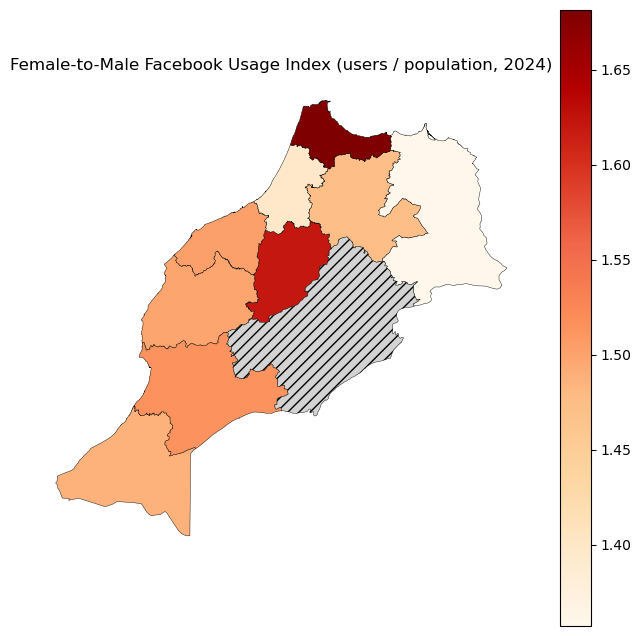

In [ ]:
import matplotlib.pyplot as plt
from unidecode import unidecode
from matplotlib.colors import TwoSlopeNorm

# ---------- Helper ----------

def norm(s: str) -> str:
    """Normalize strings for matching."""
    return (
        unidecode(str(s))
        .strip()
        .lower()
        .replace("’", "'")
        .replace("  ", " ")
    )

# ---------- 1. Map old regions -> new ADM1 (already defined) ----------

region_map = {
    "Grand Casablanca": "Grand Casablanca-Settat",
    "Fès-Boulemane": "Fès-Meknès",
    "Marrakesh-Tensift-El Haouz": "Marrakech-Safi",
    "Meknès-Tafilalet": "Fès-Meknès",
    "Rabat-Salè-Zemmour-Zaer": "Rabat-Salé-Kénitra",
    "Tangier-Tetouan": "Tanger-Tétouan-Al Hoceima",
    "Taza-Al Hoceima-Taounate": "Tanger-Tétouan-Al Hoceima",
    "Guelmim-Es Semara": "Guelmim-Oued Noun",
    "Laâyoune-Boujdour-Sakia El Hamra": "Laâyoune-Sakia El Hamra",
    "Dakhla-Oued Ed-Dahab": "Dakhla-Oued Ed Dahab",
    "Souss-Massa-Dràa": "Souss-Massa",
    "Gharb-Chrarda-Béni Hssen": "Rabat-Salé-Kénitra",
    "Chaouia-Ouardigha": "Grand Casablanca-Settat",
    "Oriental": "Oriental",
    "Doukkala-Abda": "Marrakech-Safi",
    "Tadla-Azilal": "Béni Mellal-Khénifra",
    "Morocco (all)": None,
}

region_map_norm = {
    norm(old): norm(new) for old, new in region_map.items() if new is not None
}

df_wide = df_wide.copy()
df_wide["RegionName_norm"] = df_wide["RegionName"].apply(norm)
df_wide["ADM1_target_norm"] = df_wide["RegionName_norm"].map(region_map_norm)

# Keep only rows that could be mapped (1 row per final ADM1 if your input is clean)
df_wide_mapped = df_wide.dropna(subset=["ADM1_target_norm"])

# ---------- 2. Load population by sex (2024 estimates) ----------

pop = pd.read_excel("population_maroc_regions_by_sex_2024.xlsx")
pop["ADM1_FR_norm"] = pop["Region"].apply(norm)

# ---------- 3. Merge Facebook users (per region) with population ----------

# No groupby: df_wide_mapped already has one record per region
df_users_pop = df_wide_mapped.merge(
    pop[["ADM1_FR_norm", "Females_2024", "Males_2024"]],
    left_on="ADM1_target_norm",
    right_on="ADM1_FR_norm",
    how="left"
)

# Compute population-adjusted usage rates
df_users_pop["female_rate"] = df_users_pop["MonthlyActiveUsersMid_F"] / df_users_pop["Females_2024"]
df_users_pop["male_rate"]   = df_users_pop["MonthlyActiveUsersMid_M"] / df_users_pop["Males_2024"]

# Female-to-Male Facebook usage index
df_users_pop["FM_index_ratio"] = df_users_pop["female_rate"] / df_users_pop["male_rate"]

# ---------- 4. Build ADM1 geometries ----------

adm2 = gpd.read_file(
    "mar_admbnda_hcp_20230925_shp/mar_admbnda_adm2_hcp_20230925.shp"
).to_crs(epsg=4326)

adm2["ADM1_FR_norm"] = adm2["ADM1_FR"].apply(norm)

adm1 = (
    adm2
    .dissolve(by="ADM1_FR_norm", as_index=False)[["ADM1_FR","ADM1_FR_norm", "geometry"]]
)

# ---------- 5. Merge index into GeoDataFrame ----------
df_users_pop_mean = ( # this is for the changes in the admin regions
    df_users_pop
    .groupby("ADM1_target_norm", as_index=False)
    .mean(numeric_only=True)
)

gdf = adm1.merge(
    df_users_pop_mean[["ADM1_target_norm", "FM_index_ratio"]],
    left_on="ADM1_FR_norm",
    right_on="ADM1_target_norm", 
    how="left"
)

# ---------- 6. Plot F/M index map (centered at 1) ----------
from matplotlib.colors import TwoSlopeNorm, Normalize

valid = gdf["FM_index_ratio"].dropna()
vmin, vmax = valid.min(), valid.max()

# Decide how to scale:
if vmin < 1.0 < vmax:
    # Values on both sides of 1: use diverging scale centered at 1
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)
    cmap = "RdBu_r"
else:
    # All values on one side of 1: use a regular sequential scale
    # to avoid TwoSlopeNorm error and weird offsets.
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = "OrRd"  # or any sequential colormap you prefer

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

gdf.plot(
    column="FM_index_ratio",
    ax=ax,
    legend=True,
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={
        "color": "lightgrey",
        "hatch": "///",
        "label": "No data"
    },
)

ax.set_axis_off()
ax.set_title("Female-to-Male Facebook Usage Index (users / population, 2024)", fontsize=12)

plt.show()

In [ ]:
# ---------- SDG 17.8.1 (Internet usage) ----------
file_internet = "2025 SDG 17.8.1_REV.xlsx"

# Load the Excel file to inspect available sheets
xl_internet = pd.ExcelFile(file_internet)
print("Sheets in SDG 17.8.1 file:", xl_internet.sheet_names)

# Read the first sheet (we’ll adjust later if needed)
df_internet = pd.read_excel(xl_internet, sheet_name=0)
print("\nColumns in SDG 17.8.1 file:")
print(df_internet.columns)

# ---------- SDG 5.b.1 (Mobile phone usage) ----------
file_mobile = "2025 SDG 5.b.1.xlsx"

# Load the Excel file to inspect available sheets
xl_mobile = pd.ExcelFile(file_mobile)
print("\nSheets in SDG 5.b.1 file:", xl_mobile.sheet_names)

# Read the data sheet
df_mobile = pd.read_excel(xl_mobile, sheet_name=0)
print("\nColumns in SDG 5.b.1 file:")
print(df_mobile.columns)

Sheets in SDG 17.8.1 file: ['Data', 'Nature', 'Sex', 'Units', 'Reporting Type']

Columns in SDG 17.8.1 file:
Index(['Indicator', 'SeriesID', 'SeriesDescription', 'GeoAreaCode',
       'GeoAreaName', 'TimePeriod', 'Value', 'Time_Detail', 'Source',
       'FootNote', 'Nature', 'Sex', 'Units', 'Reporting Type', 'ISOalpha3',
       'Type', 'SeriesCode', 'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')

Sheets in SDG 5.b.1 file: ['Data', 'Nature', 'Sex', 'Units', 'Reporting Type']

Columns in SDG 5.b.1 file:
Index(['Indicator', 'SeriesID', 'SeriesDescription', 'GeoAreaCode',
       'GeoAreaName', 'TimePeriod', 'Value', 'Time_Detail', 'Source',
       'FootNotes', 'Nature of Data', 'Sex', 'Units', 'Reporting Type',
       'ISOalpha3', 'Type', 'Series Code'],
      dtype='object')


In [16]:
! pip install rasterstats

In [ ]:
# ===============================
# 1. National Internet FM ratio
#    (SDG 17.8.1_REV.xlsx)
# ===============================

internet_file = "2025 SDG 17.8.1_REV.xlsx"

df_internet = pd.read_excel(internet_file, sheet_name="Data")

# Filter Morocco, latest year 2023, and keep only sex breakdown rows
mask_internet = (
    (df_internet["GeoAreaName"] == "Morocco") &
    (df_internet["Time_Detail"] == 2021) &
    (df_internet["Sex"].isin(["FEMALE", "MALE", "BOTHSEX"]))
)

internet_ma = df_internet[mask_internet].copy()

# Pivot to get one row with columns by sex
internet_pivot = (
    internet_ma
    .pivot_table(
        index=["GeoAreaName", "Time_Detail"],
        columns="Sex",
        values="Value",
        aggfunc="first"   
    )
    .reset_index()
)

internet_female = float(internet_pivot.loc[0, "FEMALE"])
internet_male = float(internet_pivot.loc[0, "MALE"])
internet_both = float(internet_pivot.loc[0, "BOTHSEX"])

internet_fm_ratio_national = internet_female / internet_male

print("Internet usage (Morocco, 2021)")
print(f"Female: {internet_female}")
print(f"Male:   {internet_male}")
print(f"Both:   {internet_both}")
print(f"National Internet F/M ratio: {internet_fm_ratio_national:.3f}")


# ===============================
# 2. National Mobile FM ratio
#    (SDG 5.b.1.xlsx)
# ===============================

mobile_file = "2025 SDG 5.b.1.xlsx"

df_mobile = pd.read_excel(mobile_file, sheet_name="Data")

mask_mobile = (
    (df_mobile["GeoAreaName"] == "Morocco") &
    (df_mobile["Time_Detail"] == 2023) &
    (df_mobile["Sex"].isin(["FEMALE", "MALE", "BOTHSEX"]))
)

mobile_ma = df_mobile[mask_mobile].copy()

mobile_pivot = (
    mobile_ma
    .pivot_table(
        index=["GeoAreaName", "Time_Detail"],
        columns="Sex",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

mobile_female = float(mobile_pivot.loc[0, "FEMALE"])
mobile_male = float(mobile_pivot.loc[0, "MALE"])
mobile_both = float(mobile_pivot.loc[0, "BOTHSEX"])

mobile_fm_ratio_national = mobile_female / mobile_male

print("\nMobile phone use (Morocco, 2023)")
print(f"Female: {mobile_female}")
print(f"Male:   {mobile_male}")
print(f"Both:   {mobile_both}")
print(f"National Mobile F/M ratio: {mobile_fm_ratio_national:.3f}")


Internet usage (Morocco, 2021)
Female: 86.4
Male:   89.9
Both:   88.1
National Internet F/M ratio: 0.961

Mobile phone use (Morocco, 2023)
Female: 96.5
Male:   97.0
Both:   96.8
National Mobile F/M ratio: 0.995


In [18]:
import pandas as pd

# Population totals (Morocco)
female_pop_nat = 18_879_151
male_pop_nat = 19_202_022

# Filter the Morocco (all) row
row_nat = df_wide[df_wide["RegionName"] == "Morocco (all)"].iloc[0]

# Extract national MAU for each gender
facebook_female_mau_nat = row_nat["MonthlyActiveUsersMid_F"]
facebook_male_mau_nat = row_nat["MonthlyActiveUsersMid_M"]

# Compute Facebook usage rates (share of population using Facebook)
facebook_female_rate_nat = facebook_female_mau_nat / female_pop_nat
facebook_male_rate_nat = facebook_male_mau_nat / male_pop_nat

# Compute national Facebook female-to-male ratio
facebook_fm_ratio_national = facebook_female_rate_nat / facebook_male_rate_nat

print("National Facebook usage (Morocco):")
print(f"Female MAU: {facebook_female_mau_nat:,.0f}")
print(f"Male MAU:   {facebook_male_mau_nat:,.0f}")
print(f"Female population: {female_pop_nat:,}")
print(f"Male population:   {male_pop_nat:,}")
print(f"Female rate: {facebook_female_rate_nat:.3f}")
print(f"Male rate:   {facebook_male_rate_nat:.3f}")
print(f"Facebook F/M national ratio: {facebook_fm_ratio_national:.3f}")


National Facebook usage (Morocco):
Female MAU: 15,750,000
Male MAU:   11,850,000
Female population: 18,879,151
Male population:   19,202,022
Female rate: 0.834
Male rate:   0.617
Facebook F/M national ratio: 1.352


In [26]:
import pandas as pd
import geopandas as gpd


# --- Step 3. Estimate regional internet usage by gender ---

overall_internet_rate = internet_fm_ratio_national

gdf["male_internet_rate_est"] = overall_internet_rate * 2 / (1 + gdf["FM_index_ratio_adj"])
gdf["female_internet_rate_est"] = gdf["FM_index_ratio_adj"] * gdf["male_internet_rate_est"]

# --- Step 4. Inspect results ---
print(gdf[["ADM1_FR", "FM_index_ratio", "FM_index_ratio_adj",
           "female_internet_rate_est", "male_internet_rate_est"]])


                     ADM1_FR  FM_index_ratio  FM_index_ratio_adj  \
0       Béni Mellal-Khénifra        1.621129            1.152510   
1             Drâa-Tafilalet             NaN                 NaN   
2                 Fès-Meknès        1.473967            1.047888   
3    Grand Casablanca-Settat        1.502362            1.068075   
4          Guelmim-Oued Noun        1.487481            1.057496   
5             Marrakech-Safi        1.497844            1.064864   
6                   Oriental        1.357111            0.964812   
7         Rabat-Salé-Kénitra        1.397347            0.993417   
8                Souss-Massa        1.514432            1.076656   
9  Tanger-Tétouan-Al Hoceima        1.681338            1.195315   

   female_internet_rate_est  male_internet_rate_est  
0                  1.029162                0.892974  
1                       NaN                     NaN  
2                  0.983542                0.938594  
3                  0.992703        

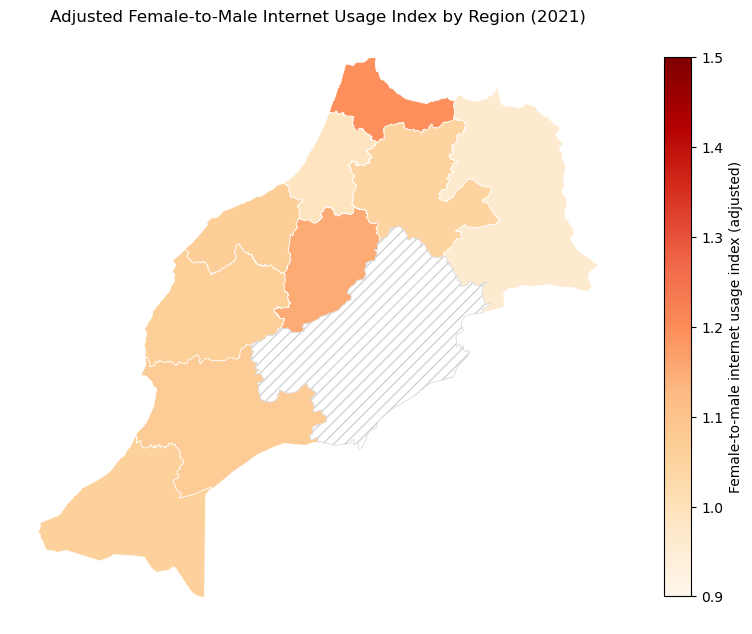

In [27]:
# 1. Compute adjusted female-to-male internet index per region
gdf["FM_internet_index_est"] = (
    gdf["female_internet_rate_est"] / gdf["male_internet_rate_est"]
)

# 2. Prepare data for plotting
var = "FM_internet_index_est"
gdf_nonan = gdf[~gdf[var].isna()].copy()

vmin = 0.9
vmax = 1.5

# 3. Plot map
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

gdf_nonan.plot(
    column=var,
    ax=ax,
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="white",
    vmin=vmin,
    vmax=vmax,
)

# Hatched polygons for regions without data
gdf[gdf[var].isna()].plot(
    ax=ax,
    color="none",
    edgecolor="lightgrey",
    hatch="///",
    linewidth=0.5,
)

ax.set_axis_off()

# 4. Colorbar
norm = Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="OrRd", norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label("Female-to-male internet usage index (adjusted)", fontsize=10)

# 5. Title
ax.set_title(
    "Adjusted Female-to-Male Internet Usage Index by Region (2021)",
    fontsize=12,
)

plt.tight_layout()
plt.show()


National overall mobile phone usage rate (BOTHSEX, 2023): 96.800


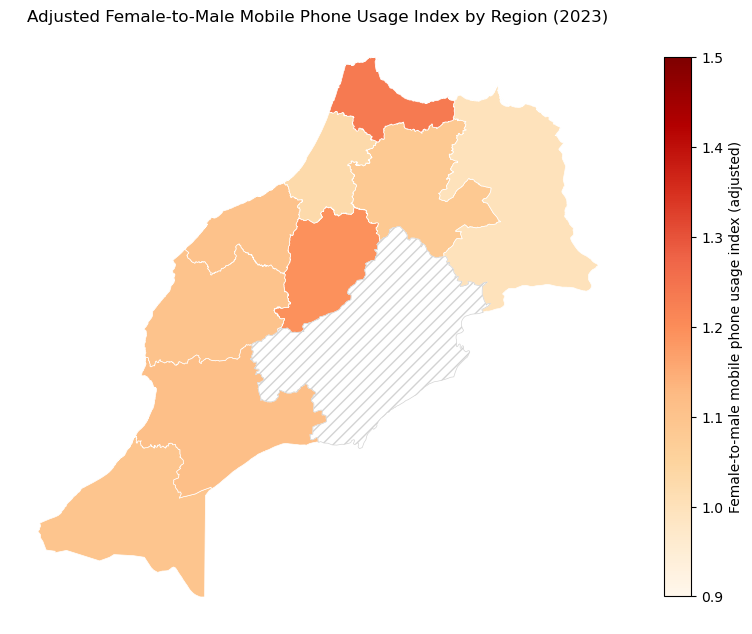

In [28]:
# ----------------------------------------------------------
# 1. Get national overall mobile phone usage rate (BOTHSEX)
# ----------------------------------------------------------
mask_nat_mobile = (
    (df_mobile["GeoAreaName"] == "Morocco") &
    (df_mobile["Time_Detail"] == 2023) &
    (df_mobile["Sex"] == "BOTHSEX")
)
overall_mobile_rate = float(df_mobile.loc[mask_nat_mobile, "Value"].iloc[0])

print(f"National overall mobile phone usage rate (BOTHSEX, 2023): {overall_mobile_rate:.3f}")

# ----------------------------------------------------------
# 2. Build adjusted female-to-male mobile index by region
#    (Option 1: rescale Facebook FM pattern to match mobile FM national)
# ----------------------------------------------------------
gdf["FM_mobile_index_adj"] = (
    gdf["FM_index_ratio"] * (mobile_fm_ratio_national / facebook_fm_ratio_national)
)

# ----------------------------------------------------------
# 4. Prepare labels per region (one value per ADM1_FR)
# ----------------------------------------------------------
var = "FM_mobile_index_est"
gdf_nonan = gdf[~gdf[var].isna()].copy()

# Dissolve to one polygon per region
gdf_labels_mobile = (
    gdf_nonan
    .dissolve(by="ADM1_FR", as_index=False)
)

# Mean FM index per region
fm_mobile_by_region = (
    gdf_nonan.groupby("ADM1_FR")[var]
    .mean()
    .reset_index()
    .rename(columns={var: "FM_mobile_index_region"})
)

gdf_labels_mobile = gdf_labels_mobile.merge(
    fm_mobile_by_region,
    on="ADM1_FR",
    how="left"
)

# Representative point for text labels
gdf_labels_mobile["rep_point"] = gdf_labels_mobile.geometry.representative_point()
gdf_labels_mobile["x"] = gdf_labels_mobile["rep_point"].x
gdf_labels_mobile["y"] = gdf_labels_mobile["rep_point"].y

# ----------------------------------------------------------
# 5. Plot mobile FM index map with labels
# ----------------------------------------------------------
vmin = 0.9
vmax = 1.5

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Choropleth
gdf_nonan.plot(
    column=var,
    ax=ax,
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="white",
    vmin=vmin,
    vmax=vmax,
)

# Hatched for missing
gdf[gdf[var].isna()].plot(
    ax=ax,
    color="none",
    edgecolor="lightgrey",
    hatch="///",
    linewidth=0.5,
)



ax.set_axis_off()

# Colorbar
norm = Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="OrRd", norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label("Female-to-male mobile phone usage index (adjusted)", fontsize=10)

# Title
ax.set_title(
    "Adjusted Female-to-Male Mobile Phone Usage Index by Region (2023)",
    fontsize=12,
)

plt.tight_layout()
plt.show()
